# Discrete Diffusion

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/gpeyre/ot4ml/blob/main/python/8-discrete_diffusion.ipynb)

This notebook is a self-contained mathematical tutorial interleaving derivations and numerics for finite-state diffusion.

Global objective:
- define a forward noising process that transports the data law $h^0$ toward a simple limit law $h^{\infty}$,
- define a backward process that recovers $h^0$ when run from terminal time,
- learn this backward process from samples generated by the forward noising dynamics.

Roadmap:
- **Forward Noising Process**: model definition and forward simulation,
- **Backward Kernels and Coupling**: admissible reverse kernels, Bayes inverse, and coupling viewpoint,
- **Learning the Reverse Kernel**: parametric estimation of reverse transitions,
- **Connection with Classical Gaussian Diffusion**: continuous-state limit and score-based formulation.


## Forward Noising Process


We work on $\mathcal X=\{0,\dots,n-1\}$ and histograms $h^t\in\Delta_n$.
A forward Markov kernel satisfies $P\mathbf 1=\mathbf 1$, and the evolution is
$$
h^{t+1}=P^\top h^t.
$$
For particles,
$$
X_{t+1}\sim P(X_t,\cdot),\qquad X_0\sim h^0.
$$

For readability, the entry $P_{ij}$ can also be written as $P(j\mid i)$, since it is a conditional probability.
We use both notations depending on context.

In large-scale applications, $n$ can be very large (or effectively infinite), so explicit matrix storage is typically replaced by structured/factored parameterizations (for example causal factorizations in NLP). This notebook treats the explicit finite-matrix setting.

In the geometric 1D example used below,
$$
P(j\mid i)\propto \exp\!\left(-\frac{(i-j)^2}{2\sigma^2}\right),
\qquad
\sum_j P(j\mid i)=1,
$$
with $\sigma=0.75$.


In [1]:

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

np.random.seed(0)
torch.manual_seed(0)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using torch device: {device}")

n = 30
T = 100
N = 20000
sigma = .75


Using torch device: cpu


In [2]:

# Forward kernel P (Gaussian convolution, row-normalized)
i = np.arange(n)[:, None]
j = np.arange(n)[None, :]
K = np.exp(-((i - j) ** 2) / (2.0 * sigma ** 2))
P = K / K.sum(axis=1, keepdims=True)

# Initial histogram h^0
spikes = (np.array([0.1, 0.6, 0.8]) * n).astype(int)
amps = np.array([1.0, 1.4, 0.6], dtype=np.float64)
amps = amps / amps.sum()

h0 = np.zeros(n, dtype=np.float64)
h0[spikes] = amps


The next cell defines helper functions for categorical sampling and visualization (trajectories and histogram snapshots).


In [3]:
def sample_categorical_batch(prob):
    cdf = np.cumsum(prob, axis=1)
    u = np.random.rand(prob.shape[0], 1)
    return (u > cdf).sum(axis=1)


def plot_trajectories(Z, title, reverse_time=False, num_show=30):
    TT = Z.shape[1] - 1
    if reverse_time:
        x = np.arange(TT, -1, -1)   # t=T ... 0
    else:
        x = np.arange(0, TT + 1)     # t=0 ... T

    idx = np.linspace(0, Z.shape[0] - 1, min(num_show, Z.shape[0]), dtype=int)
    colors = plt.cm.hsv(np.linspace(0, 1, len(idx), endpoint=False))

    plt.figure(figsize=(10, 4))
    for c, k in zip(colors, idx):
        plt.plot(x, Z[k], color=c, alpha=0.4, linewidth=1.2)
    if reverse_time:
        plt.xlim(TT, 0)
    plt.xlabel('time')
    plt.ylabel('state index')
    plt.title(title + f' (showing {len(idx)} trajectories)')
    plt.tight_layout()
    plt.show()


def plot_histograms(H, title, reverse_time=False):
    nn, Tp1 = H.shape
    TT = Tp1 - 1

    fig, axes = plt.subplots(5, 1, figsize=(8, 10), sharex=True)
    blue = np.array([0.0, 0.0, 1.0])
    red = np.array([1.0, 0.0, 0.0])

    if reverse_time:
        t_steps = np.array([TT, 15, 5, 1, 0], dtype=int)
        t_steps = np.unique(np.clip(t_steps, 0, TT))[::-1]
        s_steps = TT - t_steps
        alphas = np.linspace(0.0, 1.0, len(t_steps))  # blue -> red
        colors = [(1-a)*blue + a*red for a in alphas]
        for ax, s, t, c in zip(axes, s_steps, t_steps, colors):
            ax.bar(np.arange(nn), H[:, s], color=c)
            ax.set_ylabel(f't={t}')
    else:
        t_steps = np.array([0, 1, 5, 15, TT], dtype=int)
        t_steps = np.unique(np.clip(t_steps, 0, TT))
        alphas = np.linspace(1.0, 0.0, len(t_steps))  # red -> blue
        colors = [(1-a)*blue + a*red for a in alphas]
        for ax, t, c in zip(axes, t_steps, colors):
            ax.bar(np.arange(nn), H[:, t], color=c)
            ax.set_ylabel(f't={t}')

    axes[-1].set_xlabel('state index')
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


Forward simulation and exact histogram recursion are computed together:
$$
X_{t+1}^{(m)}\sim P(X_t^{(m)},\cdot),
\qquad
h^{t+1}=P^\top h^t.
$$


We store:
- trajectories $X\in\{0,\dots,n-1\}^{N\times(T+1)}$,
- exact marginals $H[:,t]=h^t$.

Forward displays show 30 colored trajectories and histogram snapshots at $t\in\{0,1,5,15,T\}$.


In [4]:

X = np.zeros((N, T + 1), dtype=np.int64)
H = np.zeros((n, T + 1), dtype=np.float64)

X[:, 0] = np.random.choice(n, size=N, p=h0)
H[:, 0] = h0

for t in range(T):
    cur = X[:, t]
    X[:, t + 1] = sample_categorical_batch(P[cur, :])
    H[:, t + 1] = P.T @ H[:, t]


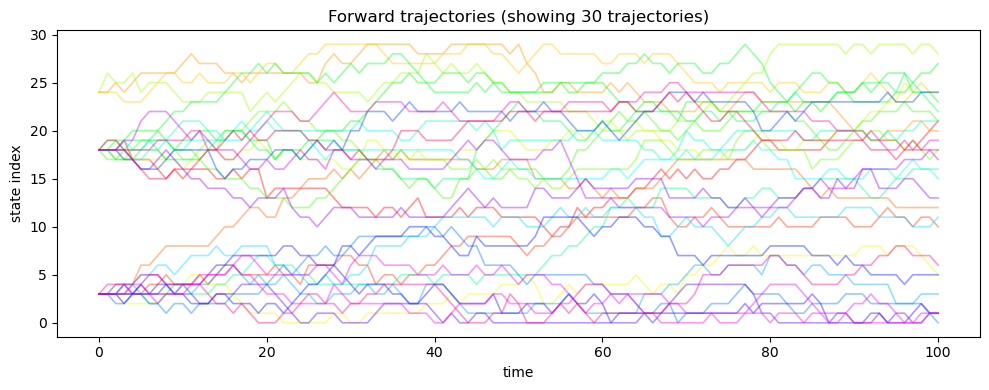

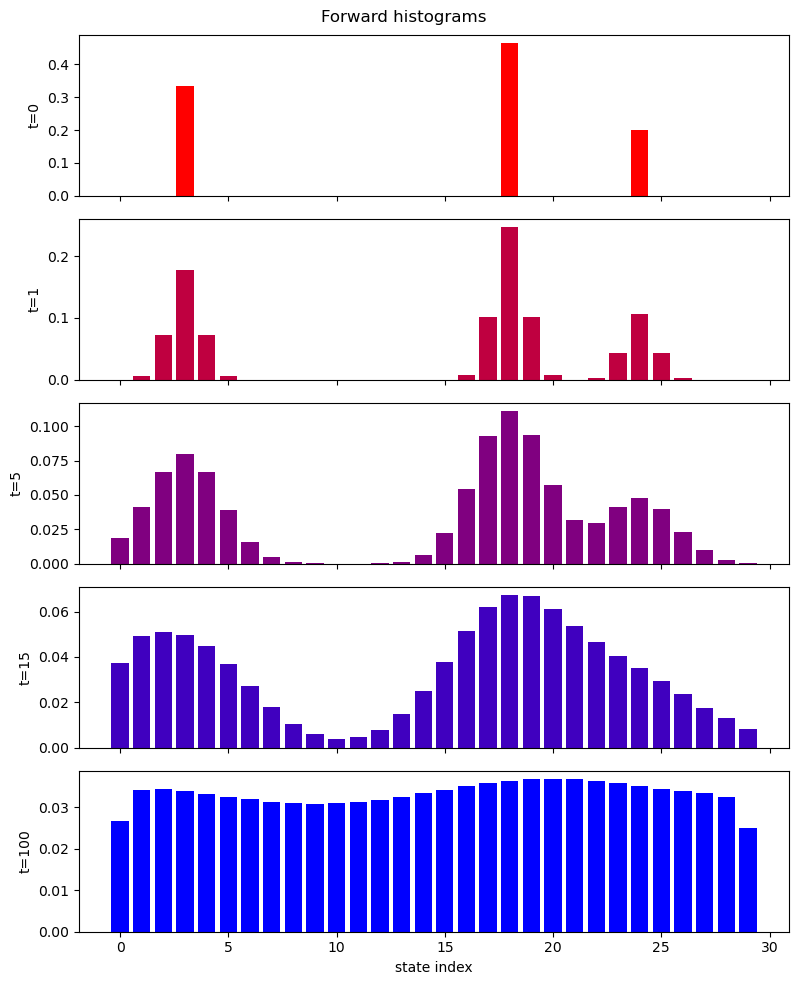

In [5]:

plot_trajectories(X, 'Forward trajectories', reverse_time=False, num_show=30)
plot_histograms(H, 'Forward histograms', reverse_time=False)


## Backward Kernels and Coupling


We now construct reverse dynamics from $t=T$ to $t=0$ with marginals $(h^t)$, so that terminal backward samples follow the data law $h^0$.

For $a,b\in\Delta_n$, admissible kernels are
$$
\mathcal T(a,b):=\{K\in\mathbb R_+^{n\times n}:\ K\mathbf 1=\mathbf 1,\ K^\top a=b\}.
$$
At each step,
$$
Q^t\in\mathcal T(h^{t+1},h^t).
$$
Backward particle process:
$$
Y_T\sim h^T,
\qquad
Y_t\sim Q^t(Y_{t+1},\cdot),\quad t=T-1,\dots,0.
$$


_Bayes inverse as a canonical admissible reverse kernel._

With $a:=h^t$, $b:=h^{t+1}$ and $P\in\mathcal T(a,b)$, define
$$
Q^{\mathrm B,t}_{ij} := \mathbb P(X_t=j\mid X_{t+1}=i)
= \frac{a_j P(i\mid j)}{b_i},
$$
that is
$$
Q^{\mathrm B,t} := \operatorname{Diag}(b)^+P^\top\operatorname{Diag}(a),
$$
with row normalization in finite precision.

Define the Bayesian inversion map
$$
\psi_{a,b}:\mathcal T(a,b)\to\mathcal T(b,a),
\qquad
\psi_{a,b}(K):=\operatorname{Diag}(b)^+K^\top\operatorname{Diag}(a).
$$
On supports where $a_i,b_i>0$, this is a bijection with inverse $\psi_{b,a}$.


_Coupling polytope and bijection with kernels._

Define the set of couplings between two histograms $a,b$ as
$$
\Pi(a,b):=\{\pi\in\mathbb R_+^{n\times n}:\ \pi\mathbf 1=a,\ \pi^\top\mathbf 1=b\}.
$$
The kernel-coupling bijection is
$$
\Phi_{a,b}:\mathcal T(a,b)\to\Pi(a,b),
\qquad
\Phi_{a,b}(K):=\operatorname{Diag}(a)K,
$$
with inverse
$$
\Phi_{a,b}^{-1}(\pi)=\operatorname{Diag}(a)^+\pi.
$$

Let $\mathsf T:\Pi(a,b)\to\Pi(b,a)$ be transposition, $\mathsf T(\pi):=\pi^\top$.
Then Bayes inversion is exactly the composition
$$
\psi_{a,b}=\Phi_{b,a}^{-1}\circ \mathsf T\circ \Phi_{a,b}.
$$
Indeed, for $K\in\mathcal T(a,b)$,
$$
\psi_{a,b}(K)
=\operatorname{Diag}(b)^+K^\top\operatorname{Diag}(a)
=\Phi_{b,a}^{-1}\!\big((\Phi_{a,b}(K))^\top\big).
$$
So transposition on couplings and Bayesian inversion on kernels are the same map written in two coordinate systems.


In [6]:

Q = np.zeros((T, n, n), dtype=np.float64)

for t in range(T):
    D_t = np.diag(H[:, t])
    inv_h_next = np.where(H[:, t + 1] > 0, 1.0 / H[:, t + 1], 0.0)
    D_next_pinv = np.diag(inv_h_next)

    Q_t = D_next_pinv @ P.T @ D_t

    rs = Q_t.sum(axis=1, keepdims=True)
    zero_rows = (rs[:, 0] == 0)
    Q_t[~zero_rows] = Q_t[~zero_rows] / rs[~zero_rows]
    Q_t[zero_rows] = 1.0 / n

    Q[t] = Q_t


We inspect the central row in log-scale,
$$
\log Q^t_{\lfloor n/2\rfloor,:},
$$
for $t\in\{0,1,2,n\}$ (first, early, late reverse transitions).\n

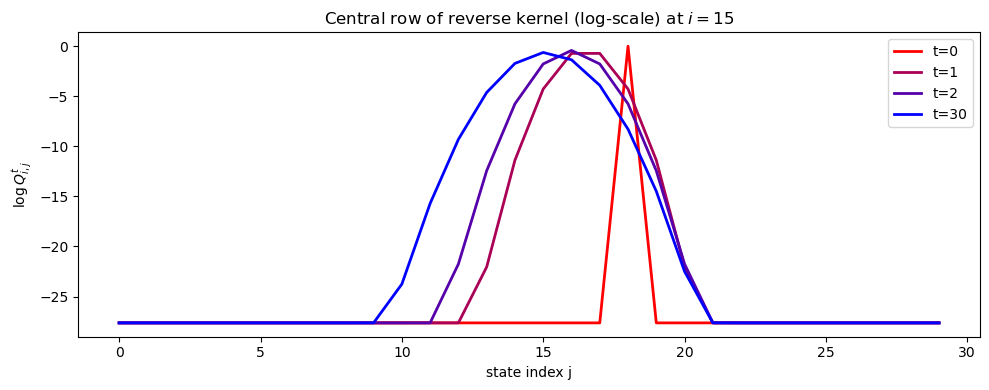

In [7]:

i_mid = n // 2
t_show_disp = np.array([0, 1, 2, n], dtype=int)
t_show = np.clip(t_show_disp, 0, T - 1)

red = np.array([1.0, 0.0, 0.0])
blue = np.array([0.0, 0.0, 1.0])
alphas = np.linspace(0.0, 1.0, len(t_show))
colors = [(1.0 - a) * red + a * blue for a in alphas]

eps_log = 1e-12
x = np.arange(n)
plt.figure(figsize=(10, 4))
for td, t, c in zip(t_show_disp, t_show, colors):
    plt.plot(x, np.log(Q[t, i_mid, :] + eps_log), color=c, linewidth=2.0, label=f't={td}')
plt.xlabel('state index j')
plt.ylabel(r'$\log Q^t_{i,j}$')
plt.title(rf'Central row of reverse kernel (log-scale) at $i={i_mid}$')
plt.legend()
plt.tight_layout()
plt.show()


Backward simulation is initialized at terminal forward law:
$$
Y_T\sim h^T=H[:,T].
$$
We report:
- empirical backward histograms $G$ from particles,
- deterministic backward recursion $G_{\mathrm{exact}}$,
- consistency errors against forward marginals $H$.


In [8]:

Y = np.zeros((N, T + 1), dtype=np.int64)
Y[:, 0] = np.random.choice(n, size=N, p=H[:, T])

for s in range(T):
    t = T - 1 - s
    cur = Y[:, s]
    Y[:, s + 1] = sample_categorical_batch(Q[t, cur, :])

G = np.zeros((n, T + 1), dtype=np.float64)
for s in range(T + 1):
    cnt = np.bincount(Y[:, s], minlength=n)
    G[:, s] = cnt / cnt.sum()

G_exact = np.zeros((n, T + 1), dtype=np.float64)
G_exact[:, 0] = H[:, T]
for s in range(T):
    t = T - 1 - s
    G_exact[:, s + 1] = Q[t].T @ G_exact[:, s]

err_exact = max(np.abs(G_exact[:, s] - H[:, T - s]).sum() for s in range(T + 1))
err_mc_t0 = np.abs(G[:, T] - H[:, 0]).sum()

print(f'deterministic max L1 error (index check): {err_exact:.3e}')
print(f'empirical L1 at recovered h^0: {err_mc_t0:.4f}')


deterministic max L1 error (index check): 1.535e-14
empirical L1 at recovered h^0: 0.0062


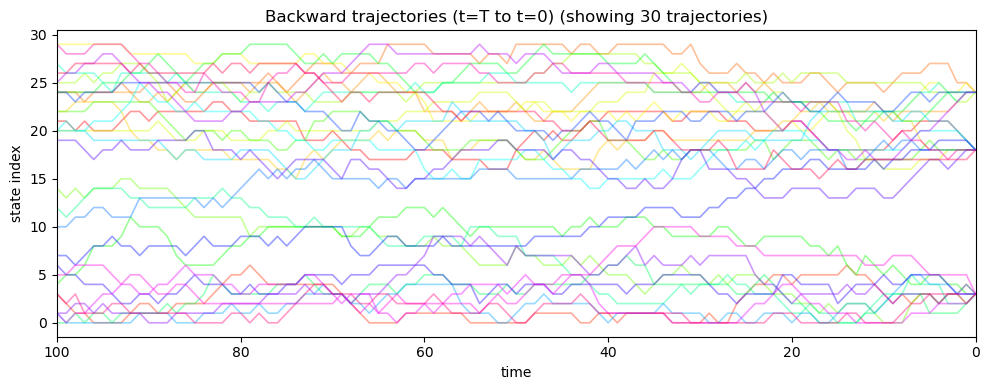

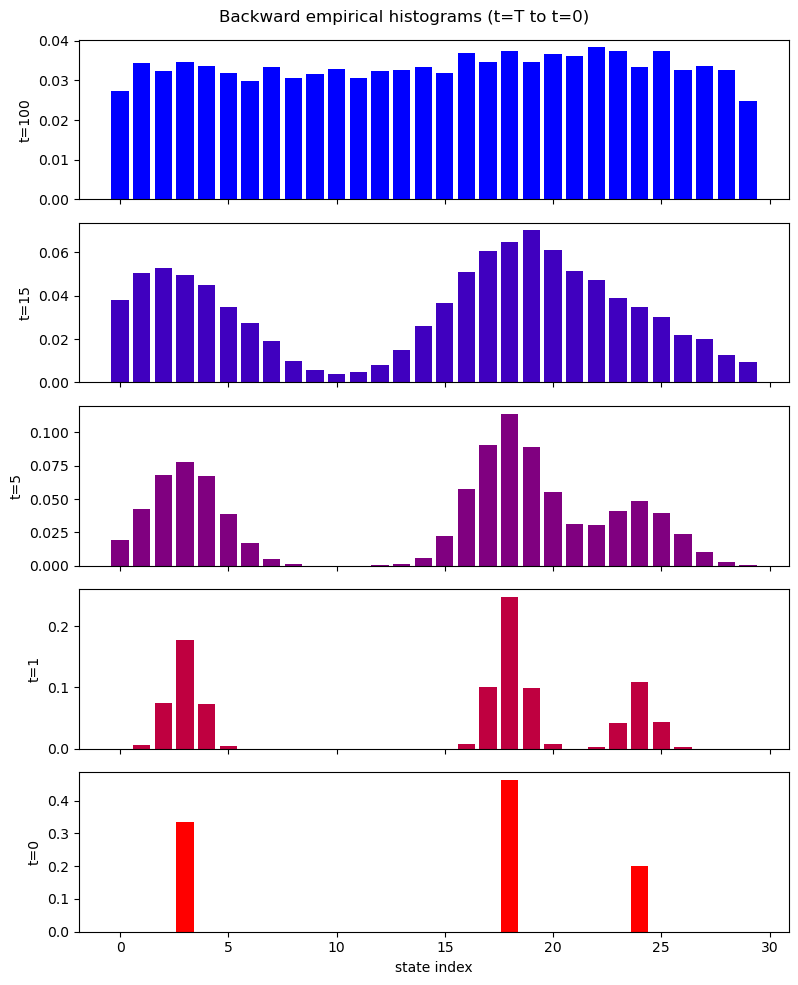

In [9]:

plot_trajectories(Y, 'Backward trajectories (t=T to t=0)', reverse_time=True, num_show=30)
plot_histograms(G, 'Backward empirical histograms (t=T to t=0)', reverse_time=True)


## Learning the Reverse Kernel


We learn a parametric reverse kernel $Q_\theta^t$, targeting the true Bayes reverse kernel
$$
Q_{\star}^t(i,\cdot):=\mathbb P(X_t=\cdot\mid X_{t+1}=i,t+1).
$$
The model aims at
$$
Q_\theta^t(i,\cdot)\approx Q_\star^t(i,\cdot).
$$
In this geometric 1D setting, we encode
$$
x=\frac{i}{n-1}\in[0,1],
\qquad
\tau=\frac{t}{T}\in[0,1],
$$
and feed $(x,\tau)$ to a 2-layer MLP (hidden width $p=4n$, one ReLU, final softmax).


In [10]:
class ReverseNet(nn.Module):
    def __init__(self, n, hidden):
        super().__init__()
        self.fc1 = nn.Linear(2, hidden)
        self.fc2 = nn.Linear(hidden, n)

    def forward(self, x_norm, t_norm):
        # Geometric setting: encode state index x as a scalar in [0,1],
        # exactly like normalized time t; network input is 2D: (x_norm, t_norm).
        x = torch.cat([x_norm, t_norm], dim=1)
        x = F.relu(self.fc1(x))
        probs = torch.softmax(self.fc2(x), dim=1)
        return probs


Training pairs $(X_{t_m}^{(m)},X_{t_m+1}^{(m)},t_m)$ are obtained from consecutive forward states, with $t_m\in\{0,\dots,T-1\}$.

Empirical risk minimization:
$$
\theta_N\in\arg\min_\theta L_N(\theta),
\qquad
L_N(\theta):=-\frac1M\sum_{m=1}^M
\log Q_\theta^{t_m}\big(X_{t_m+1}^{(m)},X_{t_m}^{(m)}\big).
$$
Population loss:
$$
L(\theta)=\mathbb E\big[-\log Q_\theta^t(X_{t+1},X_t)\big]
= C + \sum_t\mathbb P(t)\sum_i h_i^{t+1}\,\mathrm{KL}\big(Q_\star^t(i,\cdot)\,\|\,Q_\theta^t(i,\cdot)\big).
$$
Hence, if the model class is expressive enough and optimization/statistics are consistent, minimizers recover $Q_\star^t$ on the support of sampled contexts.


In [14]:

x_prev = X[:, :-1].reshape(-1)
x_curr = X[:, 1:].reshape(-1)
t_idx = np.tile(np.arange(T), N)

x_prev_t = torch.tensor(x_prev, dtype=torch.long, device=device)
x_curr_t = torch.tensor((x_curr / (n - 1)).reshape(-1, 1), dtype=torch.float32, device=device)
t_norm_t = torch.tensor((t_idx / max(T - 1, 1)).reshape(-1, 1), dtype=torch.float32, device=device)

print(f't index range for training pairs: {t_idx.min()}..{t_idx.max()} (expected 0..{T-1})')

p_hidden = 4 * n
model = ReverseNet(n=n, hidden=p_hidden).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

batch_size = 4096
epochs = 40*5
M = x_prev_t.shape[0]

for epoch in range(1, epochs + 1):
    perm = torch.randperm(M, device=device)
    running = 0.0
    for start in range(0, M, batch_size):
        idx = perm[start:start + batch_size]
        probs = model(x_curr_t[idx], t_norm_t[idx])
        picked = probs[torch.arange(idx.numel(), device=device), x_prev_t[idx]].clamp_min(1e-12)
        loss = -torch.log(picked).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running += loss.item() * idx.numel()

    if epoch % 5 == 0 or epoch == 1:
        print(f'epoch {epoch:02d} | NLL {running / M:.4f}')


t index range for training pairs: 0..99 (expected 0..99)
epoch 01 | NLL 2.5776
epoch 05 | NLL 1.4226
epoch 10 | NLL 1.1733
epoch 15 | NLL 1.1108
epoch 20 | NLL 1.0949
epoch 25 | NLL 1.0901
epoch 30 | NLL 1.0884
epoch 35 | NLL 1.0876
epoch 40 | NLL 1.0873
epoch 45 | NLL 1.0870
epoch 50 | NLL 1.0867
epoch 55 | NLL 1.0865
epoch 60 | NLL 1.0862
epoch 65 | NLL 1.0860
epoch 70 | NLL 1.0860
epoch 75 | NLL 1.0857
epoch 80 | NLL 1.0857
epoch 85 | NLL 1.0857
epoch 90 | NLL 1.0855
epoch 95 | NLL 1.0855
epoch 100 | NLL 1.0855
epoch 105 | NLL 1.0856
epoch 110 | NLL 1.0855
epoch 115 | NLL 1.0853
epoch 120 | NLL 1.0855
epoch 125 | NLL 1.0853
epoch 130 | NLL 1.0854
epoch 135 | NLL 1.0854
epoch 140 | NLL 1.0853
epoch 145 | NLL 1.0854
epoch 150 | NLL 1.0853
epoch 155 | NLL 1.0854
epoch 160 | NLL 1.0853
epoch 165 | NLL 1.0852
epoch 170 | NLL 1.0854
epoch 175 | NLL 1.0851
epoch 180 | NLL 1.0852
epoch 185 | NLL 1.0852
epoch 190 | NLL 1.0851
epoch 195 | NLL 1.0853
epoch 200 | NLL 1.0852


In [16]:

with torch.no_grad():
    t_grid = np.repeat(np.arange(T), n)
    i_grid = np.tile(np.arange(n), T)

    probs = model(
        torch.tensor((i_grid / (n - 1)).reshape(-1, 1), dtype=torch.float32, device=device),
        torch.tensor((t_grid / max(T - 1, 1)).reshape(-1, 1), dtype=torch.float32, device=device),
    )
    Q_hat = probs.detach().cpu().numpy().reshape(T, n, n)

e = 1e-12
kl = (Q * (np.log(Q + e) - np.log(Q_hat + e))).sum(axis=2).mean()
l1 = np.abs(Q - Q_hat).sum(axis=2).mean()

print(f'mean KL(Q || Q_hat) = {kl:.6f}')
print(f'mean L1(Q, Q_hat)   = {l1:.6f}')

# Diagnostics: the MLE objective weights rows by context frequency h_i^{t+1}.
row_kl = (Q * (np.log(Q + e) - np.log(Q_hat + e))).sum(axis=2)
context_mass = H[:, 1:].T
weighted_kl = (row_kl * context_mass).sum() / context_mass.sum()
unweighted_kl = row_kl.mean()

print(f'weighted mean row KL (training-relevant): {weighted_kl:.6f}')
print(f'unweighted mean row KL: {unweighted_kl:.6f}')


mean KL(Q || Q_hat) = 0.034684
mean L1(Q, Q_hat)   = 0.062610
weighted mean row KL (training-relevant): 0.001972
unweighted mean row KL: 0.034684


Rows with very small context mass $h_i^{t+1}$ receive little weight in transition-NLL training, so some row-wise slices can be less accurate visually even when the weighted objective is low.

Comparison in log-scale at $i=\lfloor n/2\rfloor$ for
$$
t\in\{0,1,2,n\}.
$$
Solid lines: $\log Q^t_{i,:}$, dashed lines: $\log \hat Q^t_{i,:}$.

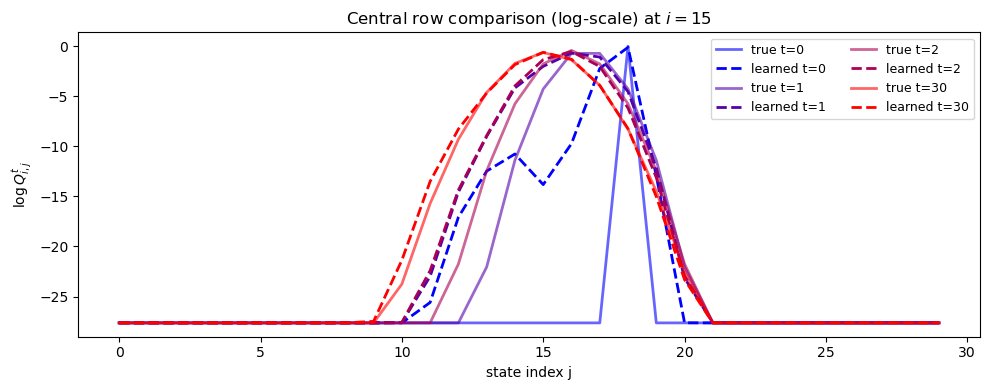

In [17]:

i_mid = n // 2
t_disp = np.array([0, 1, 2, n], dtype=int)
t_idx = np.clip(t_disp, 0, T - 1)

blue = np.array([0.0, 0.0, 1.0])
red = np.array([1.0, 0.0, 0.0])
alphas = np.linspace(0.0, 1.0, len(t_idx))
colors = [(1.0 - a) * blue + a * red for a in alphas]

eps_log = 1e-12
x = np.arange(n)
plt.figure(figsize=(10, 4))
for td, t, c in zip(t_disp, t_idx, colors):
    plt.plot(x, np.log(Q[t, i_mid, :] + eps_log), color=c, linestyle='-', linewidth=2, alpha=0.6, label=f'true t={td}')
    plt.plot(x, np.log(Q_hat[t, i_mid, :] + eps_log), color=c, linestyle='--', linewidth=2, label=f'learned t={td}')

plt.xlabel('state index j')
plt.ylabel(r'$\log Q^t_{i,j}$')
plt.title(rf'Central row comparison (log-scale) at $i={i_mid}$')
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()


## Connection with Classical Gaussian Diffusion


This section connects the finite-state tutorial to continuous-time, continuous-space diffusion models. It contains only mathematical derivations (no numerics here); for practical Gaussian diffusion experiments, see the dedicated Gaussian-diffusion notebook.

For continuous state $x\in\mathbb R^d$, a short-time forward noising step is
$$
X_{t+\tau}=X_t+\tau f(X_t,t)+g(t)\sqrt{\tau}\,\xi,
\qquad
\xi\sim\mathcal N(0,I).
$$
The forward transition is Gaussian to first order:
$$
p(x_{t+\tau}\mid x_t)\approx \mathcal N\big(x_t+\tau f(x_t,t),\ \tau g(t)^2I\big).
$$
Bayes inversion gives
$$
p(x_t\mid x_{t+\tau}=y)
\propto
p(x_{t+\tau}=y\mid x_t)\,p_t(x_t).
$$
Expanding for small $\tau$:
$$
X_t\mid X_{t+\tau}=y
\approx
\mathcal N\!\Big(y-\tau f(y,t)+\tau g(t)^2\nabla\log p_t(y),\ \tau g(t)^2I\Big).
$$
Therefore the reverse-time limit is
$$
dX_t=\big(f(X_t,t)-g(t)^2\nabla\log p_t(X_t)\big)dt+g(t)\,d\bar W_t.
$$
So, in continuous spaces, the reverse object is a vector field (the score), whereas in finite-state spaces we model transition kernels $Q^t$ directly.

_On a uniform grid: NLL $\to$ score matching._
Let $x_i=i\,\Delta_x$ in 1D, with a Gaussian-like discrete forward kernel, and let $(\Delta_x,\tau)\to(0,0)$. If we parameterize reverse conditionals through a drift field $v_\theta$ as
$$
Q_\theta^t(y,\cdot)\leadsto
\mathcal N\!\big(y-\tau f(y,t)+\tau g(t)^2v_\theta(y,t),\ \tau g(t)^2\big),
$$
then the population transition NLL satisfies
$$
\mathcal L(\theta)=
\mathbb E\big[-\log Q_\theta^t(X_{t+\tau},X_t)\big]
= C + \frac{\tau g(t)^2}{2}
\,\mathbb E\!\left[\big(v_\theta(X_{t+\tau},t)-\partial_x\log p_t(X_{t+\tau})\big)^2\right]
+o(\tau).
$$
Hence, up to constants and scaling, minimizing reverse-kernel NLL converges to a score-matching loss on the vector field.


## Bibliography

- Jacob Austin, Daniel Johnson, Jonathan Ho, Daniel Tarlow, and Rianne van den Berg. *Structured denoising diffusion models in discrete state-spaces*. arXiv preprint arXiv:2107.03006, 2021.

- Andrew Campbell, Joe Benton, Valentin De Bortoli, Tom Rainforth, George Deligiannidis, and Arnaud Doucet. *A continuous time framework for discrete denoising models*. arXiv preprint arXiv:2205.14987, 2022.

- Vincent Pauline, Tobias H"oppe, Kirill Neklyudov, Alexander Tong, Stefan Bauer, and Andrea Dittadi. *Foundations of diffusion models in general state spaces: A self-contained introduction*. arXiv preprint arXiv:2512.05092, 2025.
